In [1]:
import numpy as np
#1-29 is gopher


In [2]:
loaded_data = np.load("data/gopher_dataset.npz")

In [3]:
X_train = loaded_data["X_train"]
y_train = loaded_data["y_train"]
X_test = loaded_data["X_test"]
y_test = loaded_data["y_test"]

In [4]:
X_train.shape

(44, 128, 128, 3)

In [5]:
X_flat = X_train.reshape(X_train.shape[0], -1) / 255.0
X_test = X_test.reshape(X_test.shape[0], -1) / 255.0
y_train = y_train.reshape(y_train.shape[0], 1)
y_test = y_test.reshape(y_test.shape[0], 1)
X_flat.shape

(44, 49152)

In [46]:
def initialize_parameters(layer_dims):
    
    W = [np.random.randn(layer_dims[i], layer_dims[i-1]) * 0.01 for i in range(1, len(layer_dims))]
    B = [np.zeros((layer_dims[i], 1)) for i in range(1, len(layer_dims))]
    return W, B

In [47]:
layer_dims = [X_flat.shape[1], 64, 32, 1]
W, B = initialize_parameters(layer_dims)
W

[array([[-0.00751806,  0.01893184,  0.01361415, ...,  0.00448807,
         -0.01061785, -0.00269349],
        [-0.01094898, -0.01780859, -0.00807852, ..., -0.01681466,
          0.01033717,  0.01729679],
        [-0.01029283,  0.02253995, -0.00129219, ..., -0.00941284,
         -0.00815016, -0.01323904],
        ...,
        [-0.00363425,  0.02180845, -0.00031401, ...,  0.00283678,
          0.00392436, -0.00520844],
        [ 0.0082997 , -0.00329067,  0.01385598, ...,  0.00148467,
         -0.01251396, -0.01005835],
        [ 0.00951652, -0.00513523, -0.00582144, ...,  0.02574824,
          0.0098471 ,  0.00848645]], shape=(64, 49152)),
 array([[ 0.00746285,  0.00757734,  0.01851086, ..., -0.00156616,
         -0.02130672, -0.00058766],
        [ 0.00053236, -0.01235326, -0.00046899, ...,  0.00072626,
          0.00194137, -0.0101025 ],
        [-0.01471843,  0.00648944,  0.01250022, ...,  0.01235743,
          0.01966189, -0.01545807],
        ...,
        [-0.0056018 , -0.00630109, 

In [56]:
def forward_pass(X, W, B, layer_dims):
    cache = {}
    A = X.T
    for i in range(len(layer_dims) - 1):
        print(f"Layer {i+1}: W shape {W[i].shape}, B shape {B[i].shape}, A shape {A.shape}")
        Z = np.dot(W[i], A) + B[i]
        if i == len(layer_dims) - 2:  # Output layer
            A = 1 / (1 + np.exp(-Z))  # Sigmoid activation
        else:  # Hidden layers
            A = np.maximum(0, Z)  # ReLU activation
        cache[i] = (A, Z)

    return A, cache


In [59]:
def gradient_descent(X, Y, W, B, layer_dims, learning_rate = 0.01):
    y_pred, cache = forward_pass(X, W, B, layer_dims)
    epsilon = 1e-7
    y_pred_clipped = np.clip(y_pred, epsilon, 1 - epsilon) # Avoid log(0)
    cost = -np.mean(Y.T * np.log(y_pred_clipped) + (1 - Y.T) * np.log(1 - y_pred_clipped))
    gradients = {}
    
    # Output layer gradient
    output_idx = len(layer_dims) - 2
    gradients[f'dz{output_idx}'] = y_pred_clipped - Y.T
    gradients[f'dW{output_idx}'] = (1 / X.shape[0]) * np.dot(gradients[f'dz{output_idx}'], cache[output_idx - 1][0].T)
    gradients[f'dB{output_idx}'] = (1 / X.shape[0]) * np.sum(gradients[f'dz{output_idx}'], axis=1, keepdims=True)
    
    # Hidden layers gradients
    for i in range(output_idx - 1, -1, -1):
        gradients[f'dz{i}'] = np.dot(W[i + 1].T, gradients[f'dz{i + 1}']) * (cache[i][1] > 0)
        if i > 0:
            gradients[f'dW{i}'] = (1 / X.shape[0]) * np.dot(gradients[f'dz{i}'], cache[i - 1][0].T)
        else:
            gradients[f'dW{i}'] = (1 / X.shape[0]) * np.dot(gradients[f'dz{i}'], X)
        gradients[f'dB{i}'] = (1 / X.shape[0]) * np.sum(gradients[f'dz{i}'], axis=1, keepdims=True)
    
    # Update weights and biases
    for i in range(len(layer_dims) - 1):
        W[i] -= learning_rate * gradients[f'dW{i}']
        B[i] -= learning_rate * gradients[f'dB{i}']
    return W, B, cost


In [33]:
def train_model(X, Y, layer_dims, learning_rate = 0.01, epoch = 500):
    W, B = initialize_parameters(layer_dims)
    for i in range(epoch):
        W, B, cost = gradient_descent(X, Y, W, B, layer_dims, learning_rate)
        print(f"Cost for epoch {i} is {cost}")
    return W, B


In [39]:
def predict(pred):
    return (pred > 0.5).astype(int)

In [61]:
print(X_flat.shape, y_train.shape)
W, B = train_model(X_flat, y_train, layer_dims, epoch=5000)
pred = forward_pass(X_test, W, B, layer_dims)[0]

(44, 49152) (44, 1)
Layer 1: W shape (64, 49152), B shape (64, 1), A shape (49152, 44)
Layer 2: W shape (32, 64), B shape (32, 1), A shape (64, 44)
Layer 3: W shape (1, 32), B shape (1, 1), A shape (32, 44)
Cost for epoch 0 is 0.6931799028120819
Layer 1: W shape (64, 49152), B shape (64, 1), A shape (49152, 44)
Layer 2: W shape (32, 64), B shape (32, 1), A shape (64, 44)
Layer 3: W shape (1, 32), B shape (1, 1), A shape (32, 44)
Cost for epoch 1 is 0.6931724342830893
Layer 1: W shape (64, 49152), B shape (64, 1), A shape (49152, 44)
Layer 2: W shape (32, 64), B shape (32, 1), A shape (64, 44)
Layer 3: W shape (1, 32), B shape (1, 1), A shape (32, 44)
Cost for epoch 2 is 0.6931649271688837
Layer 1: W shape (64, 49152), B shape (64, 1), A shape (49152, 44)
Layer 2: W shape (32, 64), B shape (32, 1), A shape (64, 44)
Layer 3: W shape (1, 32), B shape (1, 1), A shape (32, 44)
Cost for epoch 3 is 0.6931575493750516
Layer 1: W shape (64, 49152), B shape (64, 1), A shape (49152, 44)
Layer 2: 

Layer 1: W shape (64, 49152), B shape (64, 1), A shape (49152, 44)
Layer 2: W shape (32, 64), B shape (32, 1), A shape (64, 44)
Layer 3: W shape (1, 32), B shape (1, 1), A shape (32, 44)
Layer 1: W shape (64, 49152), B shape (64, 1), A shape (49152, 12)
Layer 2: W shape (32, 64), B shape (32, 1), A shape (64, 12)
Layer 3: W shape (1, 32), B shape (1, 1), A shape (32, 12)
train acc: 0.501   test acc: 0.500
Layer 1: W shape (64, 49152), B shape (64, 1), A shape (49152, 1)
Layer 2: W shape (32, 64), B shape (32, 1), A shape (64, 1)
Layer 3: W shape (1, 32), B shape (1, 1), A shape (32, 1)


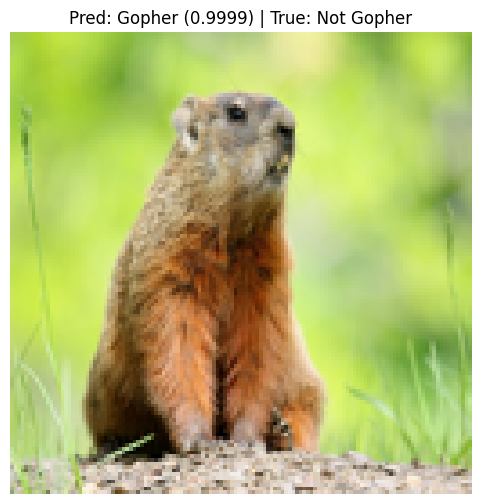

In [64]:
import matplotlib.pyplot as plt

train_acc = (predict(forward_pass(X_flat, W, B, layer_dims)[0]) == y_train).mean()
test_acc = (predict(forward_pass(X_test, W, B, layer_dims)[0]) == y_test).mean()
print(f"train acc: {train_acc:.3f}   test acc: {test_acc:.3f}")

test_image = X_test[8].reshape(1, -1)
prediction_prob = forward_pass(test_image, W, B, layer_dims)[0]
prediction = predict(prediction_prob)

img_display = (X_test[8].reshape(128, 128, 3) * 255).astype(np.uint8)

plt.figure(figsize=(6, 6))
plt.imshow(img_display)
plt.title(f"Pred: {'Gopher' if prediction[0][0] == 1 else 'Not Gopher'} ({prediction_prob[0][0]:.4f}) | True: {'Gopher' if y_test[0][0] == 1 else 'Not Gopher'}")
plt.axis('off')
plt.show()


Layer 1: W shape (64, 49152), B shape (64, 1), A shape (49152, 44)
Layer 2: W shape (32, 64), B shape (32, 1), A shape (64, 44)
Layer 3: W shape (1, 32), B shape (1, 1), A shape (32, 44)
Layer 1: W shape (64, 49152), B shape (64, 1), A shape (49152, 12)
Layer 2: W shape (32, 64), B shape (32, 1), A shape (64, 12)
Layer 3: W shape (1, 32), B shape (1, 1), A shape (32, 12)
train acc: 0.501   test acc: 0.500
Layer 1: W shape (64, 49152), B shape (64, 1), A shape (49152, 1)
Layer 2: W shape (32, 64), B shape (32, 1), A shape (64, 1)
Layer 3: W shape (1, 32), B shape (1, 1), A shape (32, 1)


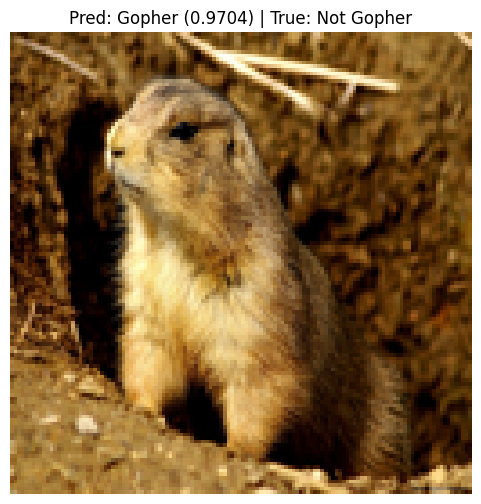

In [66]:
import matplotlib.pyplot as plt

train_acc = (predict(forward_pass(X_flat, W, B, layer_dims)[0]) == y_train).mean()
test_acc = (predict(forward_pass(X_test, W, B, layer_dims)[0]) == y_test).mean()
print(f"train acc: {train_acc:.3f}   test acc: {test_acc:.3f}")

test_image = X_test[0].reshape(1, -1)
prediction_prob = forward_pass(test_image, W, B, layer_dims)[0]
prediction = predict(prediction_prob)

img_display = (X_test[0].reshape(128, 128, 3) * 255).astype(np.uint8)

plt.figure(figsize=(6, 6))
plt.imshow(img_display)
plt.title(f"Pred: {'Gopher' if prediction[0][0] == 1 else 'Not Gopher'} ({prediction_prob[0][0]:.4f}) | True: {'Gopher' if y_test[0][0] == 1 else 'Not Gopher'}")
plt.axis('off')
plt.show()


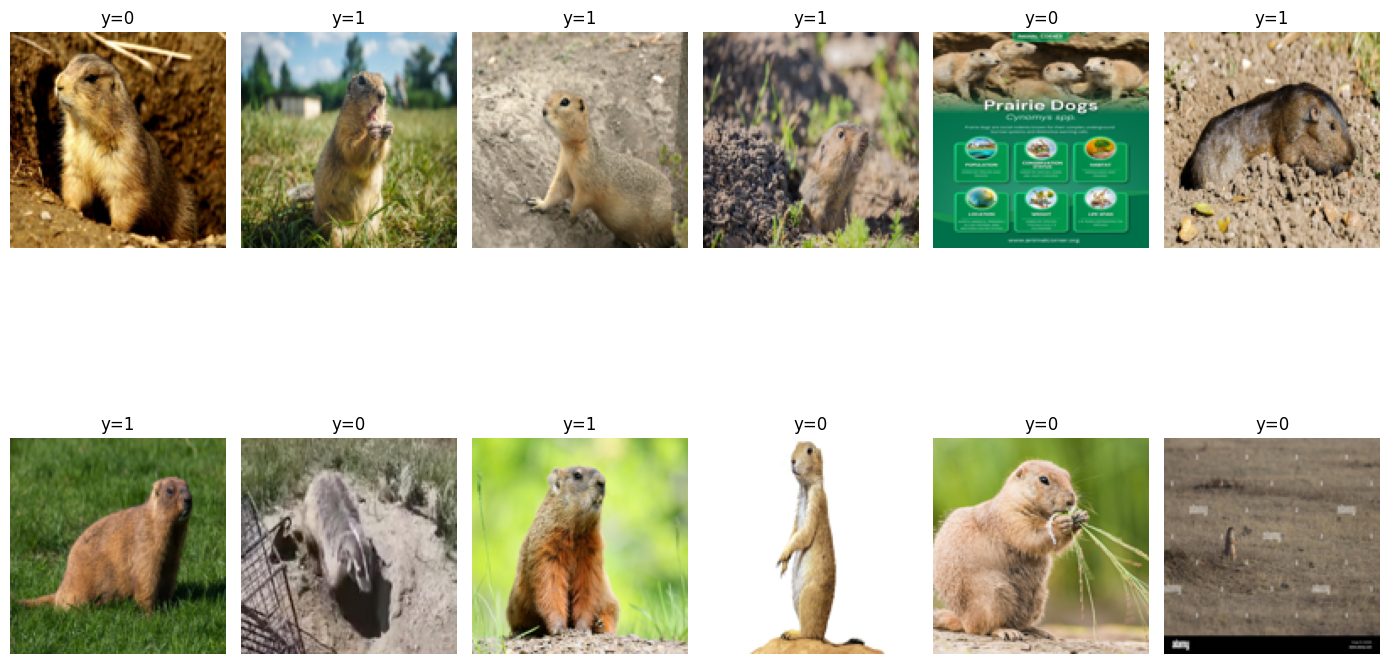

In [69]:
import matplotlib.pyplot as plt
import numpy as np

# show a grid of test images with true labels
fig, axes = plt.subplots(2, 6, figsize=(14, 10))
for i, ax in enumerate(axes.flat):
    img = (X_test[i].reshape(128, 128, 3) * 255).astype(np.uint8)
    ax.imshow(img)
    ax.set_title(f"y={int(y_test[i][0])}")
    ax.axis('off')
plt.tight_layout()
plt.show()


shapes: (1600, 32, 32, 3) (1600,) (400, 32, 32, 3) (400,)


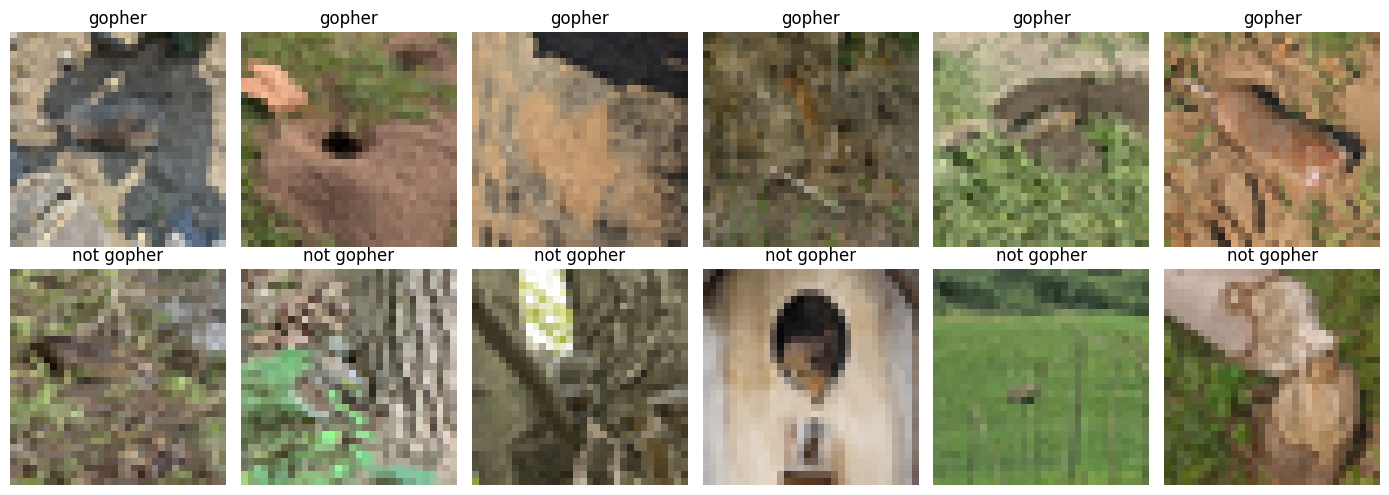

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

d = np.load("data/gopher_dataset.npz")
Xtr_raw, ytr_raw = d["X_train"], d["y_train"]
Xte_raw, yte_raw = d["X_test"], d["y_test"]
print("shapes:", Xtr_raw.shape, ytr_raw.shape, Xte_raw.shape, yte_raw.shape)

# show 6 gophers, 6 non-gophers
gophers = Xtr_raw[ytr_raw == 1][:6]
nongophers = Xtr_raw[ytr_raw == 0][:6]

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i in range(6):
    axes[0, i].imshow(gophers[i]); axes[0, i].axis("off"); axes[0, i].set_title("gopher")
    axes[1, i].imshow(nongophers[i]); axes[1, i].axis("off"); axes[1, i].set_title("not gopher")
plt.tight_layout(); plt.show()
